In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import statistics

years = range(2014,2025)

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k = 5

for year in years:
    file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_new_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [3]:
# import numpy as np
# import networkx as nx
# from sklearn.decomposition import PCA

# def calculate_hybrid_risk_metric(G, use_pca=True, custom_weights=None):
#     nodes = list(G.nodes)
#     G = G.copy()
    
#     for u, v, d in G.edges(data=True):
#         # Euclidean distance transformation bounded between 0 and sqrt(2)
#         d["distance"] = np.sqrt(2 * max(0.0, 1 - d["weight"]))
    
#     # 1. Calculate raw metrics
#     degree_dict = dict(nx.degree(G, weight="weight"))
#     closeness_dict = nx.closeness_centrality(G, distance="distance")
#     eig_dict = nx.eigenvector_centrality_numpy(G, weight="weight")
    
#     # Betweenness is calculated but not included in the hybrid metric per your thesis text
#     # betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
#     # 2. Standardize metrics using Z-scoring (mean=0, std=1)
#     def standardize_dict(d, invert=False):
#         vals = np.array(list(d.values()))
#         mean_val = vals.mean()
#         std_val = vals.std()
        
#         if std_val == 0:
#             return {k: 0.0 for k in d.keys()}
            
#         z_scores = {k: (v - mean_val) / std_val for k, v in d.items()}
        
#         if invert:
#             z_scores = {k: -v for k, v in z_scores.items()}
            
#         return z_scores

#     norm_degree = standardize_dict(degree_dict, invert=False)
#     norm_closeness = standardize_dict(closeness_dict, invert=False)
#     norm_eig = standardize_dict(eig_dict, invert=False)
    
#     # 3. Determine Weights
#     if use_pca:
#         # Build feature matrix (N nodes x 3 metrics)
#         features = np.array([
#             [norm_degree[n], norm_closeness[n], norm_eig[n]] for n in nodes
#         ])
        
#         # Extract the First Principal Component
#         pca = PCA(n_components=1)
#         pca.fit(features)
#         pc1_loadings = pca.components_[0]
        
#         # PCA vectors can point in arbitrary directions. We take the absolute value
#         # to ensure positive loadings, maintaining the logical direction of centrality.
#         pc1_loadings = np.abs(pc1_loadings)
        
#         # Normalize to sum to 1 (convex combination)
#         pca_weights = pc1_loadings / np.sum(pc1_loadings)
        
#         weights = {
#             'degree': pca_weights[0],
#             'closeness': pca_weights[1],
#             'eigenvector': pca_weights[2]
#         }
#     else:
#         # Fallback to custom or equal weights if PCA is disabled
#         weights = custom_weights if custom_weights else {
#             'degree': 1/3, 'closeness': 1/3, 'eigenvector': 1/3
#         }

#     # 4. Combine metrics with weights
#     risk_scores = {}
#     for node in nodes:
#         score = (
#             weights['degree'] * norm_degree[node] +
#             weights['closeness'] * norm_closeness[node] +
#             weights['eigenvector'] * norm_eig[node] 
#         )
#         risk_scores[node] = score
    
#     return risk_scores, weights

In [4]:
df = pd.read_parquet("../../data/02_clean/df_metrics.parquet")

In [8]:
df_long = df[["year", "node", "hrm"]].rename(columns={
    "node":"stock", "hrm":"risk"
})

df_long

,year,stock,risk
0,2014,A,-0.113502
1,2014,AA,-0.242146
2,2014,AAL,-0.411204
3,2014,AAME,-0.566156
4,2014,AAON,0.892336
...,...,...,...
40657,2024,ZTS,-0.001498
40658,2024,ZUMZ,0.723058
40659,2024,ZVRA,-0.196636
40660,2024,ZWS,0.349889


In [9]:
# risk_scores = {}
# for year in years:
#     print(f"Computing risk scores for {year}...")
#     # Add [0] here to grab only the risk_scores dictionary
#     risk_scores[year] = calculate_hybrid_risk_metric(graphs[f"graph_{year}"])[0]

# # The rest of your code will now work perfectly
# df_long = pd.DataFrame([
#     {"year": year, "stock": stock, "risk": score}
#     for year, scores in risk_scores.items()
#     for stock, score in scores.items()
# ])

In [ ]:
# # ============================================================
# # 2. SUMMARY STATISTICS TABLE
# # ============================================================
# summary_rows = []
# for year in years:
#     scores = np.array(list(risk_scores[year].values()))
#     summary_rows.append({
#         "Year":    year,
#         "Mean":    scores.mean(),
#         "Median":  np.median(scores),
#         "Std":     scores.std(),
#         "Skew":    pd.Series(scores).skew(),
#         "Kurt":    pd.Series(scores).kurt(),
#         "Min":     scores.min(),
#         "Max":     scores.max(),
#         "Q25":     np.percentile(scores, 25),
#         "Q75":     np.percentile(scores, 75),
#     })

# summary_df = pd.DataFrame(summary_rows).set_index("Year").round(4)
# print(summary_df.to_string())
# # print("\nLaTeX:\n", summary_df.to_latex())

      Mean  Median     Std    Skew     Kurt     Min     Max     Q25     Q75
Year                                                                       
2015  -0.0 -0.1599  0.8635  2.9593  13.2199 -1.1397  5.8690 -0.5178  0.2622
2016  -0.0 -0.1896  0.8576  3.1282  15.4668 -1.0426  6.3181 -0.5090  0.2825
2017  -0.0 -0.1615  0.8510  3.1060  15.5261 -1.0662  6.3630 -0.4977  0.2703
2018   0.0 -0.2170  0.8443  3.0832  15.4629 -1.0576  6.1674 -0.4746  0.2651
2019  -0.0 -0.2188  0.8366  2.9433  14.4252 -1.1555  6.1660 -0.4908  0.2003
2020   0.0 -0.2183  0.8909  2.7810  11.7924 -1.0590  5.8848 -0.5566  0.2677
2021   0.0 -0.2091  0.8815  2.9462  14.7089 -0.9875  7.0698 -0.5658  0.2798
2022   0.0 -0.2115  0.8912  2.7918  12.1575 -1.2296  5.9298 -0.5404  0.2913
2023  -0.0 -0.2155  0.8785  2.8750  15.0554 -1.0948  7.3482 -0.5818  0.3288
2024   0.0 -0.2261  0.8871  2.6561  11.6990 -1.0687  6.6545 -0.5670  0.2820


In [10]:
centralities = ["central", "peripheral"]
portfolios = {}

for year in years:
    for centrality in centralities:
        cols = pd.read_csv(f"../../data/06_portfolios/{centrality}_{year}_{k}.csv", index_col="Date").columns.tolist()
        try:
            portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_new_{year-k}_{year}.parquet")[cols]
        except:
            portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_new_{year-k+1}_{year}.parquet")[cols]

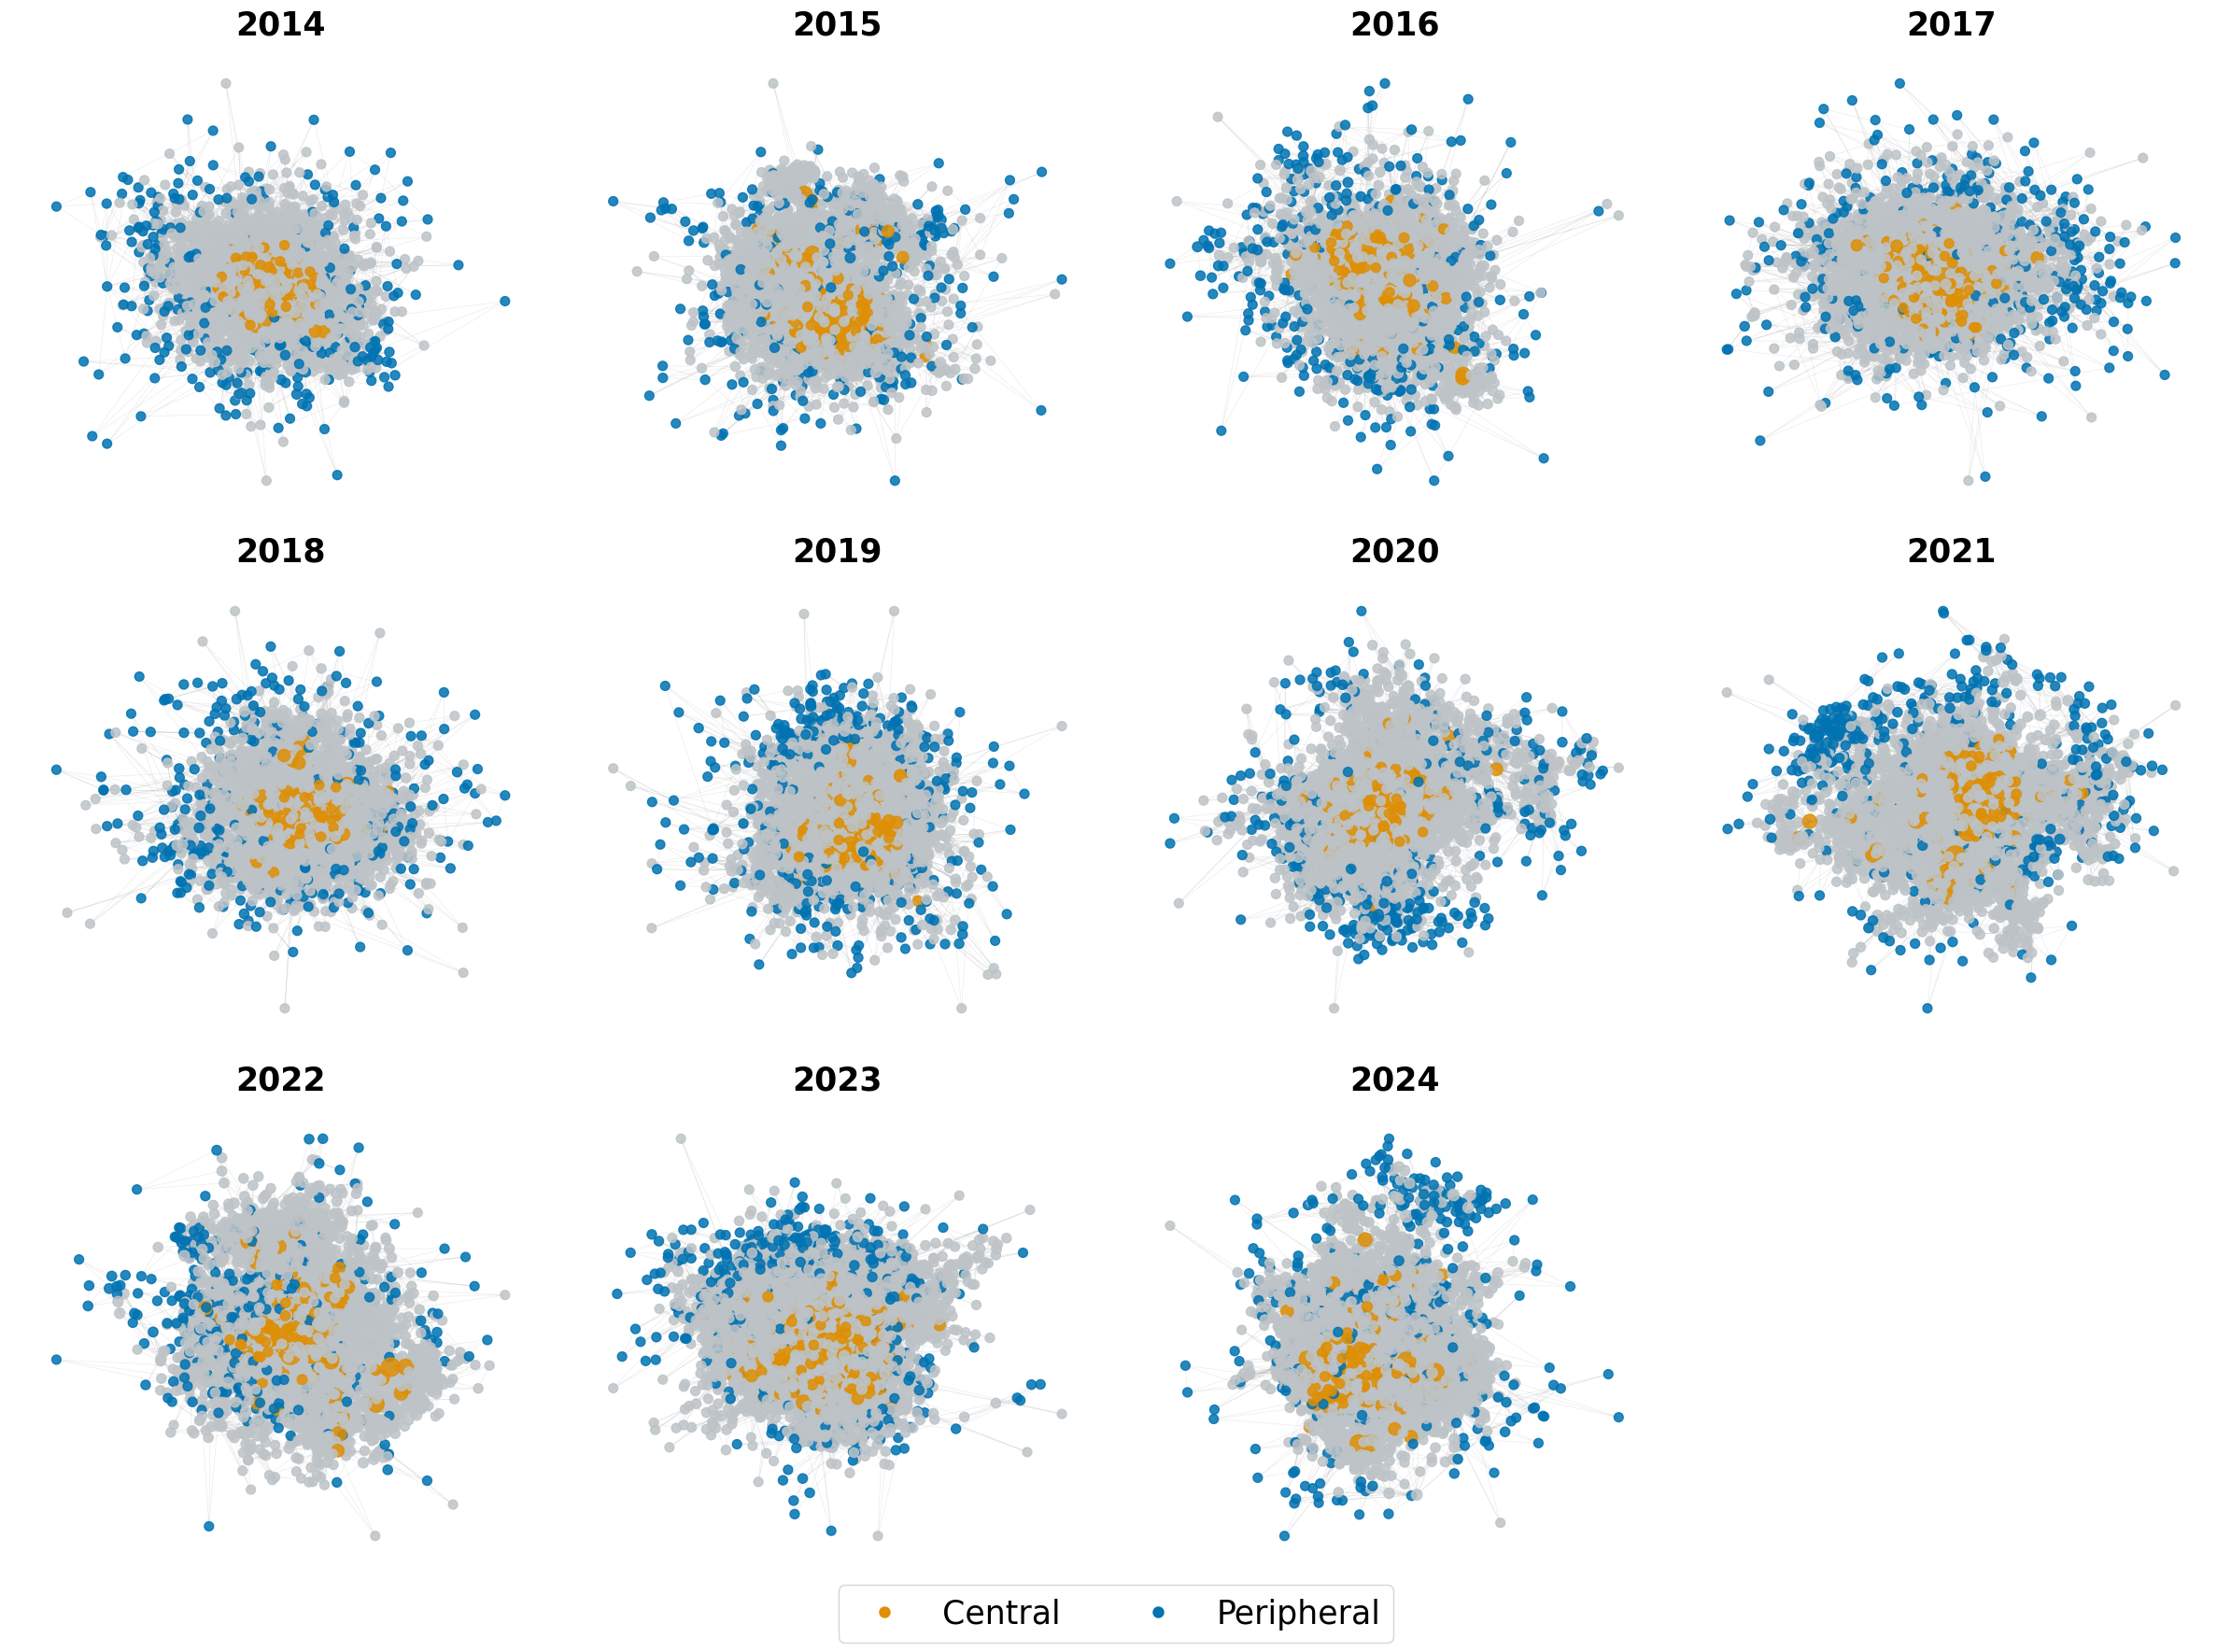

In [13]:
from matplotlib.lines import Line2D

# Adaptado para suportar até 12 anos (grade 3x4)
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

for ax, year in zip(axes.flat, years):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    central_tickers    = set(portfolios[f"central_{year}"].columns)
    peripheral_tickers = set(portfolios[f"peripheral_{year}"].columns)

    palette = sns.color_palette("colorblind")

    central_color = palette[1]
    peripheral_color = palette[0]
    middle_color = "#BDC3C7"
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in central_tickers:
            node_colors.append(central_color)       # red  = high risk / central
        elif node in peripheral_tickers:
            node_colors.append(peripheral_color)       # green = low risk / peripheral
        else:
            node_colors.append(middle_color)       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    # labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    # nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=25, fontweight="bold")
    ax.axis("off")

# Ocultar eixos extras se houver menos anos que subplots
for ax in axes.flat[len(years):]:
    ax.set_visible(False)

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=central_color, markersize=10, label="Central"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=peripheral_color, markersize=10, label="Peripheral"),
    # Line2D([0], [0], marker="o", color="w", markerfacecolor="#BDC3C7", markersize=10, label="Middle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=25,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

# fig.suptitle("TMFG Network by Year — Central vs Peripheral Stocks", fontsize=16, fontweight="bold")
os.makedirs(f"../../figures/window_{k}", exist_ok=True)
plt.savefig(f"../../figures/window_{k}/graphs.png", dpi=300)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()